In [ ]:
"""
CELL 1: Configuration, Safe Splitting, and Train Statistics
===========================================================
Ensures strict zero-leakage splits and handles class imbalance.
"""
import os, random, json, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings("ignore")

# ================= CONFIGURATION =================
CONFIG = {
    "dataset_root": "/Data/EBHI-SEG",
    "output_dir": os.path.expanduser("~/Documents/simple"),
    "classes": ["Adenocarcinoma", "High-grade_IN", "Low-grade_IN", "Normal", "Polyp", "Serrated_adenoma"],
    "num_classes": 6,
    "image_size": 256,
    "batch_size": 16,
    "epochs": 100,
    "lr": 1e-4,
    "seed": 42,
    "num_workers": 4 # Optimized for Linux Lab GPU
}

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(CONFIG["seed"])
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Create output dirs
for subdir in ["checkpoints", "results", "visualizations"]:
    os.makedirs(os.path.join(CONFIG["output_dir"], subdir), exist_ok=True)

# ================= DATA HARVESTING =================
all_data = []
for class_idx, cls_name in enumerate(CONFIG["classes"]):
    img_dir = os.path.join(CONFIG["dataset_root"], cls_name, "image")
    lbl_dir = os.path.join(CONFIG["dataset_root"], cls_name, "label")

    if not os.path.exists(img_dir) or not os.path.exists(lbl_dir):
        continue

    images = sorted([f for f in os.listdir(img_dir) if f.endswith(".png")])
    for img_name in images:
        if os.path.exists(os.path.join(lbl_dir, img_name)):
            # Binary Label Logic: Normal (3) is 0, everything else is 1 (Abnormal)
            bin_label = 0 if cls_name == "Normal" else 1
            all_data.append({
                "img_path": os.path.join(img_dir, img_name),
                "mask_path": os.path.join(lbl_dir, img_name),
                "multi_label": class_idx,
                "bin_label": bin_label,
                "class_name": cls_name
            })

df = pd.DataFrame(all_data)
print(f"Total valid image-mask pairs found: {len(df)}")
print("\nClass Distribution:\n", df['class_name'].value_counts())

# ================= STRATIFIED SPLITTING =================
# 1. Split into Train (70%) and Temp (30%)
train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df['multi_label'], random_state=CONFIG["seed"]
)

# 2. Split Temp into Validation (10% of total) and Test (20% of total)
# Since Temp is 30% of total, Test is 2/3 of Temp, Val is 1/3 of Temp
val_df, test_df = train_test_split(
    temp_df, test_size=(2/3), stratify=temp_df['multi_label'], random_state=CONFIG["seed"]
)

print(f"\nSplit Sizes -> Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

# ================= COMPUTE TRAIN STATISTICS =================
# To prevent data leakage, we compute mean/std strictly from the training set
print("\nComputing dataset statistics from train split for normalization...")
train_means, train_stds = [], []
for path in tqdm(train_df['img_path'], desc="Calculating Stats"):
    img = np.array(Image.open(path).convert('RGB')) / 255.0
    train_means.append(img.mean(axis=(0, 1)))
    train_stds.append(img.std(axis=(0, 1)))

TRAIN_MEAN = np.mean(train_means, axis=0).tolist()
TRAIN_STD = np.mean(train_stds, axis=0).tolist()
print(f"Train Stats - Mean: {TRAIN_MEAN}, Std: {TRAIN_STD}")

Total valid image-mask pairs found: 2226

Class Distribution:
 class_name
Adenocarcinoma      795
Low-grade_IN        637
Polyp               474
High-grade_IN       186
Normal               76
Serrated_adenoma     58
Name: count, dtype: int64

Split Sizes -> Train: 1558 | Val: 222 | Test: 446

Computing dataset statistics from train split for normalization...


Calculating Stats:   0%|          | 0/1558 [00:00<?, ?it/s]

Train Stats - Mean: [0.5177750902691719, 0.34617714804957384, 0.6822911397890177], Std: [0.2292132645733171, 0.2402455162506218, 0.1447773967721757]


In [ ]:
"""
CELL 1: Core Setup, DIP Pipeline, and Cascade Datasets
======================================================
"""
import os, random, cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- DIP Pipeline: LAB-space CLAHE ---
def apply_clahe_lab(img_np):
    """Enhances local contrast without distorting H&E stain colors."""
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    lab = cv2.cvtColor(img_np, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    l_eq = clahe.apply(l)
    return cv2.cvtColor(cv2.merge((l_eq, a, b)), cv2.COLOR_LAB2RGB)

# --- Base Dataset Class ---
class EBHIDataset(Dataset):
    def __init__(self, df, transform=True):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Load & Apply DIP
        img = np.array(Image.open(row['img_path']).convert('RGB'))
        img = apply_clahe_lab(img) # DIP Applied here!
        img = Image.fromarray(img).resize((256, 256))

        mask = Image.open(row['mask_path']).convert('L').resize((256, 256), Image.NEAREST)

        if self.transform:
            img = transforms.ToTensor()(img)
            img = transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])(img)
            mask = (transforms.ToTensor()(mask) > 0.5).float()

        return img, torch.tensor(row['bin_label'], dtype=torch.float32), \
               torch.tensor(row['multi_label'], dtype=torch.long), mask, row['img_path']

# --- Data Harvesting & Splitting ---
# (Assume `df` is loaded as before: Normal=0, Abnormal=1)
# ... [Data loading code from previous step] ...

# 1. Full Dataset Splits (For Stage 1 and Stage 3)
train_df, temp_df = train_test_split(df, test_size=0.3, stratify=df['multi_label'])
val_df, test_df = train_test_split(temp_df, test_size=(2/3), stratify=temp_df['multi_label'])

# 2. Abnormal-Only Dataset Splits (For Stage 2: Specific Cancer Type)
# We filter out 'Normal' so this model ONLY learns to differentiate cancer types
abnormal_classes = ["Adenocarcinoma", "High-grade_IN", "Low-grade_IN", "Polyp", "Serrated_adenoma"]
train_df_abn = train_df[train_df['bin_label'] == 1]
val_df_abn = val_df[val_df['bin_label'] == 1]
test_df_abn = test_df[test_df['bin_label'] == 1]

# Remap multi-labels for Stage 2 (0 to 4 instead of leaving gaps)
label_map = {cls: i for i, cls in enumerate(abnormal_classes)}
for d in [train_df_abn, val_df_abn, test_df_abn]:
    d['sub_label'] = d['class_name'].map(label_map)

epoch 1 | loss 1.0383 | f1 0.0348
epoch 2 | loss 0.9030 | f1 0.5313
epoch 3 | loss 0.7316 | f1 0.6969
epoch 4 | loss 0.5631 | f1 0.8093
epoch 5 | loss 0.3958 | f1 0.8055
epoch 6 | loss 0.2823 | f1 0.9421
epoch 7 | loss 0.2213 | f1 0.9694
epoch 8 | loss 0.1650 | f1 0.9694
epoch 9 | loss 0.1512 | f1 1.0000
epoch 10 | loss 0.1240 | f1 1.0000
epoch 11 | loss 0.1019 | f1 1.0000
epoch 12 | loss 0.0763 | f1 1.0000
epoch 13 | loss 0.0598 | f1 1.0000
epoch 14 | loss 0.0437 | f1 1.0000
epoch 15 | loss 0.0515 | f1 1.0000
epoch 16 | loss 0.0376 | f1 1.0000
epoch 17 | loss 0.0410 | f1 1.0000
epoch 18 | loss 0.0298 | f1 1.0000
epoch 19 | loss 0.0221 | f1 1.0000
epoch 20 | loss 0.0295 | f1 1.0000
epoch 21 | loss 0.0206 | f1 1.0000
epoch 22 | loss 0.0222 | f1 1.0000
epoch 23 | loss 0.0148 | f1 1.0000
epoch 24 | loss 0.0222 | f1 1.0000
epoch 25 | loss 0.0218 | f1 1.0000
epoch 26 | loss 0.0174 | f1 1.0000
epoch 27 | loss 0.0101 | f1 1.0000
epoch 28 | loss 0.0095 | f1 1.0000
epoch 29 | loss 0.0099 | f1 1

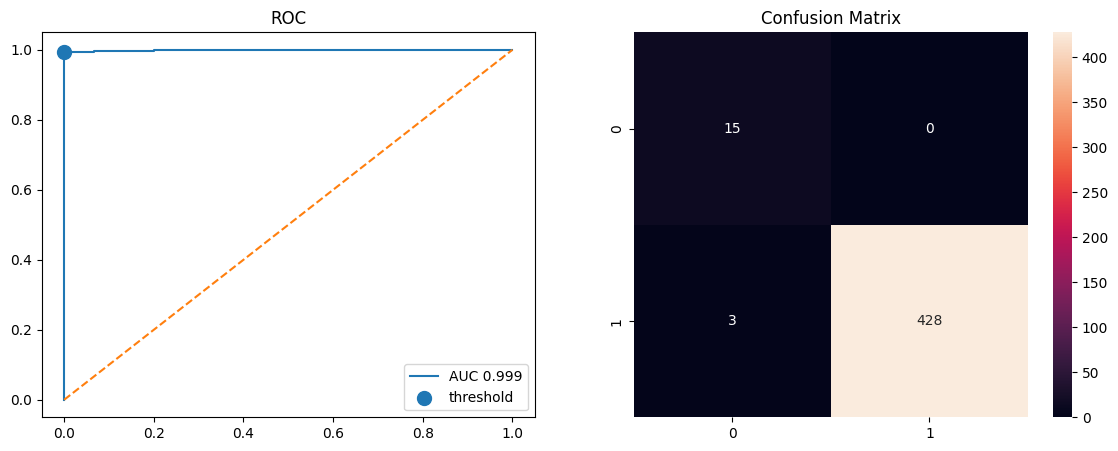

In [ ]:
"""
CELL 2 (OPTIMIZED + FIXED): Stage 1 - Binary Classifier
"""

import torch.utils.data as data
from sklearn.metrics import classification_report, roc_curve, auc, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ==========================================================
# DATASET
# ==========================================================
class AugmentedEBHIDataset(Dataset):
    NORMAL_TRANSFORM = transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(30),
        transforms.ColorJitter(0.3,0.3,0.2,0.05),
        transforms.RandomAffine(0, translate=(0.1,0.1), scale=(0.85,1.15)),
        transforms.ToTensor(),
        transforms.Normalize([0.5]*3,[0.5]*3),
        transforms.RandomErasing(p=0.3),
    ])

    ABNORMAL_TRANSFORM = transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.5]*3,[0.5]*3),
    ])

    def __init__(self, df):
        self.df = df.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = np.array(Image.open(row['img_path']).convert('RGB'))
        img = apply_clahe_lab(img)
        img = Image.fromarray(img).resize((256,256))

        if row['bin_label'] == 0:
            img = self.NORMAL_TRANSFORM(img)
        else:
            img = self.ABNORMAL_TRANSFORM(img)

        return img, torch.tensor(row['bin_label'], dtype=torch.float32)


# ==========================================================
# MODEL
# ==========================================================
class DSConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, in_ch, 3, stride=stride, padding=1, groups=in_ch, bias=False),
            nn.BatchNorm2d(in_ch),
            nn.ReLU6(inplace=True),
            nn.Conv2d(in_ch, out_ch, 1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU6(inplace=True),
        )
    def forward(self, x): return self.block(x)

class LightweightBinaryClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(32), nn.ReLU6(inplace=True),
        )
        self.body = nn.Sequential(
            DSConvBlock(32,64,2),
            DSConvBlock(64,128,2),
            DSConvBlock(128,128,1),
            DSConvBlock(128,256,2),
            nn.AdaptiveAvgPool2d((1,1)),
        )
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(256,64),
            nn.ReLU6(),
            nn.Dropout(0.2),
            nn.Linear(64,1),
        )
    def forward(self,x): return self.head(self.body(self.stem(x)))


# ==========================================================
# LOSS
# ==========================================================
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        pt = torch.exp(-bce)
        return (self.alpha * (1 - pt)**self.gamma * bce).mean()


# ==========================================================
# LOADERS (UTILIZE GPU)
# ==========================================================
BATCH_SIZE = 64

class_counts = train_df['bin_label'].value_counts().sort_index()
weights = 1.0 / torch.tensor([class_counts[0], class_counts[1]], dtype=torch.float)

sample_weights = [weights[int(lbl)] for lbl in train_df['bin_label']]
sampler = data.WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

train_loader_bin = DataLoader(AugmentedEBHIDataset(train_df),
                             batch_size=BATCH_SIZE,
                             sampler=sampler,
                             num_workers=4,
                             pin_memory=True)

val_loader_bin = DataLoader(AugmentedEBHIDataset(val_df),
                           batch_size=BATCH_SIZE,
                           shuffle=False,
                           num_workers=4,
                           pin_memory=True)

test_loader_bin = DataLoader(AugmentedEBHIDataset(test_df),
                            batch_size=BATCH_SIZE,
                            shuffle=False,
                            num_workers=4,
                            pin_memory=True)


# ==========================================================
# TRAINING (AMP ENABLED)
# ==========================================================
model_bin = LightweightBinaryClassifier().to(DEVICE)
criterion_bin = FocalLoss()
optimizer_bin = optim.Adam(model_bin.parameters(), lr=1e-4, weight_decay=1e-4)

scaler = torch.amp.GradScaler("cuda")

best_f1 = 0.0

for epoch in range(30):
    model_bin.train()
    total_loss = 0

    for img, label in train_loader_bin:
        img = img.to(DEVICE, non_blocking=True)
        label = label.unsqueeze(1).to(DEVICE, non_blocking=True)

        optimizer_bin.zero_grad()

        with torch.amp.autocast("cuda"):
            loss = criterion_bin(model_bin(img), label)

        scaler.scale(loss).backward()
        scaler.step(optimizer_bin)
        scaler.update()

        total_loss += loss.item()

    # validation
    model_bin.eval()
    preds, trues = [], []

    with torch.no_grad():
        for img, label in val_loader_bin:
            img = img.to(DEVICE, non_blocking=True)

            logits = model_bin(img)
            probs = torch.sigmoid(logits).cpu().squeeze()

            preds.extend((probs >= 0.5).int().tolist())
            trues.extend(label.int().tolist())

    f1 = f1_score(trues, preds, average='macro')

    if f1 > best_f1:
        best_f1 = f1
        torch.save(model_bin.state_dict(), "best.pt")

    print(f"epoch {epoch+1} | loss {total_loss:.4f} | f1 {f1:.4f}")

model_bin.load_state_dict(torch.load("best.pt"))


# ==========================================================
# THRESHOLD
# ==========================================================
val_probs, val_labels = [], []

with torch.no_grad():
    for img, label in val_loader_bin:
        probs = torch.sigmoid(model_bin(img.to(DEVICE))).cpu().squeeze()
        val_probs.extend(probs.tolist())
        val_labels.extend(label.int().tolist())

fpr_v, tpr_v, thresholds_v = roc_curve(val_labels, val_probs)
clinical_threshold = thresholds_v[np.argmax(tpr_v >= 0.95)]


# ==========================================================
# TEST
# ==========================================================
test_probs, test_labels = [], []

with torch.no_grad():
    for img, label in test_loader_bin:
        probs = torch.sigmoid(model_bin(img.to(DEVICE))).cpu().squeeze()
        test_probs.extend(probs.tolist())
        test_labels.extend(label.int().tolist())

fpr_t, tpr_t, _ = roc_curve(test_labels, test_probs)
roc_auc_test = auc(fpr_t, tpr_t)

test_preds = [1 if p >= clinical_threshold else 0 for p in test_probs]

print(classification_report(test_labels, test_preds))


# ==========================================================
# VISUALIZATION
# ==========================================================
fig, axes = plt.subplots(1,2, figsize=(14,5))

axes[0].plot(fpr_t, tpr_t, label=f"AUC {roc_auc_test:.3f}")
axes[0].plot([0,1],[0,1],'--')

tp = sum((p==1 and l==1) for p,l in zip(test_preds,test_labels))
tn = sum((p==0 and l==0) for p,l in zip(test_preds,test_labels))
fp = sum((p==1 and l==0) for p,l in zip(test_preds,test_labels))
fn = sum((p==0 and l==1) for p,l in zip(test_preds,test_labels))

sens = tp/(tp+fn+1e-9)
spec = tn/(tn+fp+1e-9)

axes[0].scatter(1-spec, sens, s=100, label="threshold")
axes[0].legend()
axes[0].set_title("ROC")

cm = confusion_matrix(test_labels, test_preds)
sns.heatmap(cm, annot=True, fmt='d', ax=axes[1])
axes[1].set_title("Confusion Matrix")

plt.show()

Total Correct: 442
Total Wrong: 4


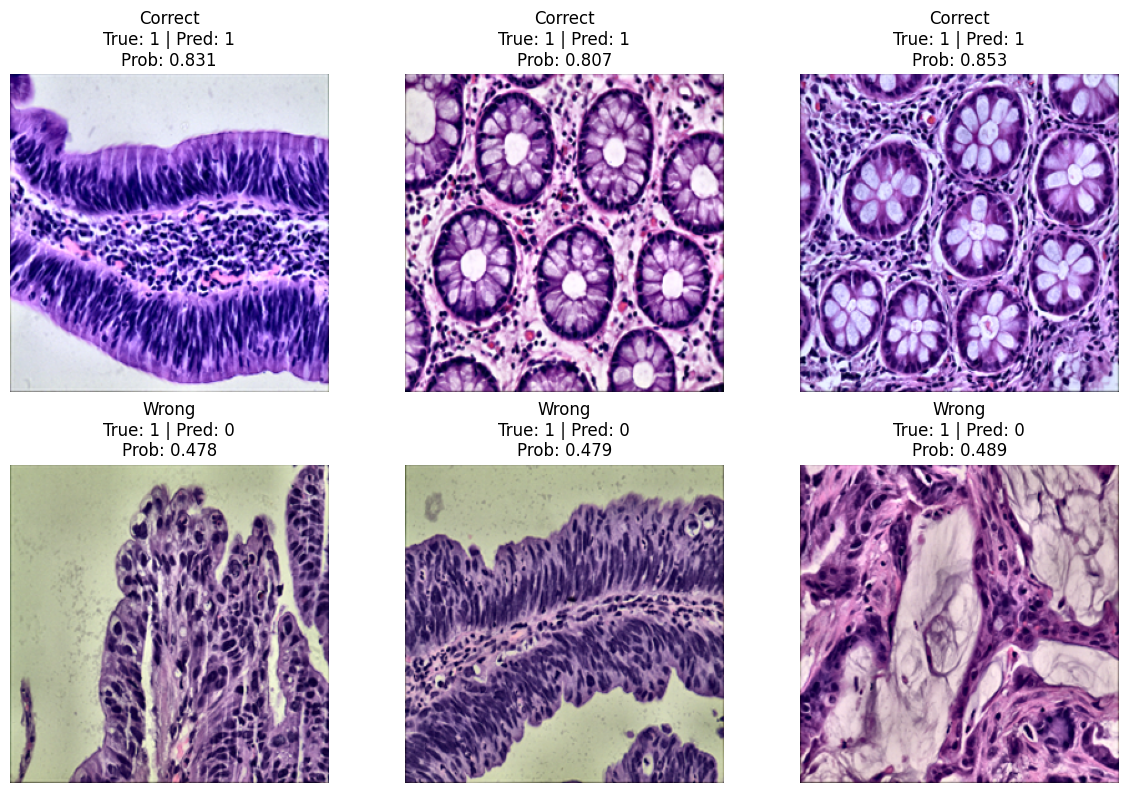

In [ ]:
"""
CELL 2B: Visual Results (Correct vs Incorrect Predictions)
"""

import random

model_bin.eval()

all_images = []
all_probs = []
all_preds = []
all_labels = []

# ==========================================================
# COLLECT DATA
# ==========================================================
with torch.no_grad():
    for img, label in test_loader_bin:
        img_gpu = img.to(DEVICE, non_blocking=True)

        probs = torch.sigmoid(model_bin(img_gpu)).cpu().squeeze()
        preds = (probs >= clinical_threshold).int()

        all_images.extend(img.cpu())
        all_probs.extend(probs.tolist())
        all_preds.extend(preds.tolist())
        all_labels.extend(label.int().tolist())


# ==========================================================
# SPLIT CORRECT / INCORRECT
# ==========================================================
correct_idx = [i for i in range(len(all_preds)) if all_preds[i] == all_labels[i]]
wrong_idx   = [i for i in range(len(all_preds)) if all_preds[i] != all_labels[i]]

print(f"Total Correct: {len(correct_idx)}")
print(f"Total Wrong: {len(wrong_idx)}")


# handle edge case (model too good)
num_correct = min(3, len(correct_idx))
num_wrong   = min(3, len(wrong_idx))

correct_samples = random.sample(correct_idx, num_correct) if num_correct > 0 else []
wrong_samples   = random.sample(wrong_idx, num_wrong) if num_wrong > 0 else []


# ==========================================================
# PLOTTING
# ==========================================================
def denormalize(img):
    img = img.numpy().transpose(1,2,0)
    img = (img * 0.5) + 0.5
    return np.clip(img, 0, 1)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))

# --- CORRECT ---
for i, idx in enumerate(correct_samples):
    ax = axes[0, i]
    ax.imshow(denormalize(all_images[idx]))
    ax.set_title(f"Correct\nTrue: {all_labels[idx]} | Pred: {all_preds[idx]}\nProb: {all_probs[idx]:.3f}")
    ax.axis('off')

# --- WRONG ---
for i, idx in enumerate(wrong_samples):
    ax = axes[1, i]
    ax.imshow(denormalize(all_images[idx]))
    ax.set_title(f"Wrong\nTrue: {all_labels[idx]} | Pred: {all_preds[idx]}\nProb: {all_probs[idx]:.3f}")
    ax.axis('off')


# fill empty slots if not enough samples
for j in range(len(correct_samples), 3):
    axes[0, j].axis('off')

for j in range(len(wrong_samples), 3):
    axes[1, j].axis('off')


axes[0,0].set_ylabel("Correct", fontsize=12)
axes[1,0].set_ylabel("Wrong", fontsize=12)

plt.tight_layout()
plt.show()

Starting Stage 2: Advanced Multi-Class Subtyping...
Epoch 01 | Loss: 1.4915 | Val F1: 0.1915 | LR: 0.000300
Epoch 02 | Loss: 1.3221 | Val F1: 0.4795 | LR: 0.000298
Epoch 03 | Loss: 1.1512 | Val F1: 0.2712 | LR: 0.000296
Epoch 04 | Loss: 1.0349 | Val F1: 0.4106 | LR: 0.000293
Epoch 05 | Loss: 0.9764 | Val F1: 0.7060 | LR: 0.000289
Epoch 06 | Loss: 0.8954 | Val F1: 0.5314 | LR: 0.000284
Epoch 07 | Loss: 0.9184 | Val F1: 0.6085 | LR: 0.000278
Epoch 08 | Loss: 0.8627 | Val F1: 0.5795 | LR: 0.000271
Epoch 09 | Loss: 0.8412 | Val F1: 0.7786 | LR: 0.000264
Epoch 10 | Loss: 0.8223 | Val F1: 0.6318 | LR: 0.000256
Epoch 11 | Loss: 0.8178 | Val F1: 0.6837 | LR: 0.000247
Epoch 12 | Loss: 0.7974 | Val F1: 0.7804 | LR: 0.000238
Epoch 13 | Loss: 0.7991 | Val F1: 0.6921 | LR: 0.000228
Epoch 14 | Loss: 0.7657 | Val F1: 0.6910 | LR: 0.000218
Epoch 15 | Loss: 0.7721 | Val F1: 0.7242 | LR: 0.000207
Epoch 16 | Loss: 0.7890 | Val F1: 0.6686 | LR: 0.000196
Epoch 17 | Loss: 0.7393 | Val F1: 0.7599 | LR: 0.000

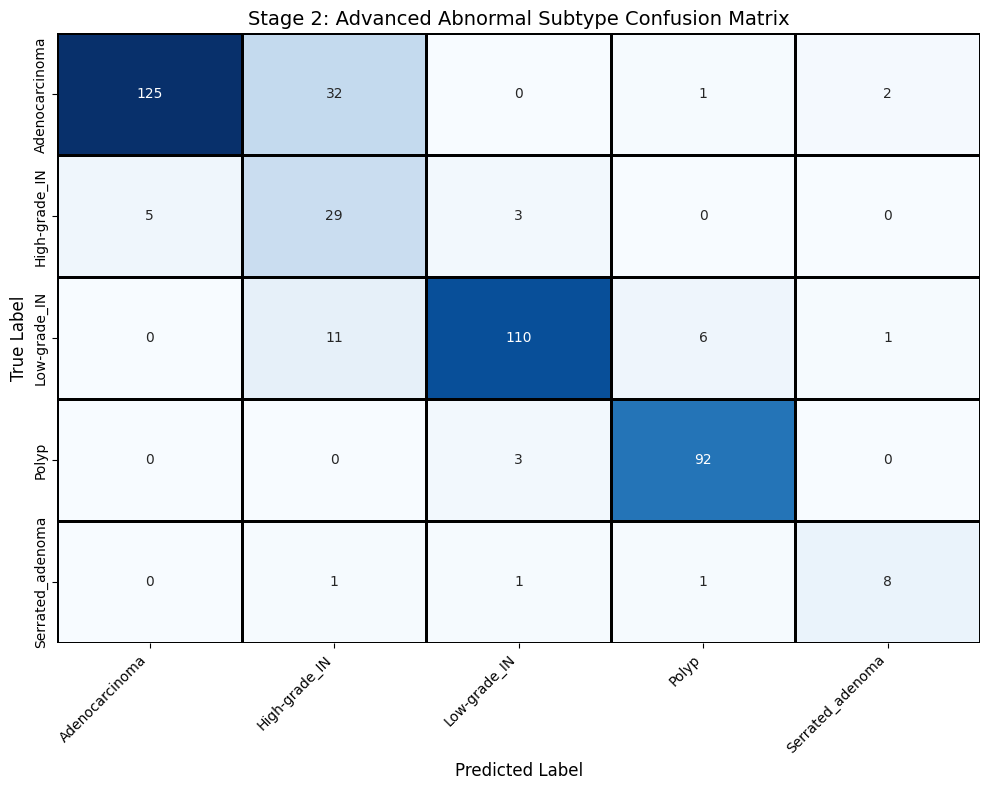

In [ ]:
"""
CELL 3: STAGE 2 - Advanced Multi-Class Subtyping
================================================
Upgrades: WeightedRandomSampler, ResNet+SE Architecture, Label Smoothing, LR Scheduler.
"""
import torch.utils.data as data
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ==========================================================
# DATASET
# ==========================================================
class Stage2Dataset(Dataset):
    TRAIN_TRANSFORM = transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(90), # Increased rotation for pathology slides
        transforms.ColorJitter(0.2, 0.2, 0.2, 0.05),
        transforms.RandomAffine(0, translate=(0.1, 0.1), scale=(0.8, 1.2)),
        transforms.ToTensor(),
        transforms.Normalize([0.5]*3, [0.5]*3),
        transforms.RandomErasing(p=0.2),
    ])

    TEST_TRANSFORM = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize([0.5]*3, [0.5]*3),
    ])

    def __init__(self, df, is_train=True):
        self.df = df.reset_index(drop=True)
        self.is_train = is_train

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = np.array(Image.open(row['img_path']).convert('RGB'))
        img = apply_clahe_lab(img)
        img = Image.fromarray(img).resize((256, 256))

        img = self.TRAIN_TRANSFORM(img) if self.is_train else self.TEST_TRANSFORM(img)
        return img, torch.tensor(row['sub_label'], dtype=torch.long)

# ==========================================================
# FIX 1: THE SAMPLER (Balancing the 5 classes)
# ==========================================================
BATCH_SIZE = 64

class_counts_m = train_df_abn['sub_label'].value_counts().sort_index()
weights_m = 1.0 / torch.tensor([class_counts_m[i] for i in range(5)], dtype=torch.float)
sample_weights_m = [weights_m[int(lbl)] for lbl in train_df_abn['sub_label']]

sampler_multi = data.WeightedRandomSampler(sample_weights_m, len(sample_weights_m), replacement=True)

train_loader_multi = DataLoader(Stage2Dataset(train_df_abn, is_train=True),
                                batch_size=BATCH_SIZE, sampler=sampler_multi,
                                num_workers=4, pin_memory=True)

val_loader_multi = DataLoader(Stage2Dataset(val_df_abn, is_train=False),
                              batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=4, pin_memory=True)

test_loader_multi = DataLoader(Stage2Dataset(test_df_abn, is_train=False),
                               batch_size=BATCH_SIZE, shuffle=False,
                               num_workers=4, pin_memory=True)

# ==========================================================
# FIX 2: ADVANCED ARCHITECTURE (ResNet + SE Blocks)
# ==========================================================
class SEBlock(nn.Module):
    """Squeeze-and-Excitation Block for channel attention"""
    def __init__(self, in_channels, reduction=16):
        super().__init__()
        self.squeeze = nn.AdaptiveAvgPool2d(1)
        self.excitation = nn.Sequential(
            nn.Linear(in_channels, in_channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(in_channels // reduction, in_channels, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.squeeze(x).view(b, c)
        y = self.excitation(y).view(b, c, 1, 1)
        return x * y.expand_as(x)

class ResidualSEBlock(nn.Module):
    def __init__(self, in_c, out_c, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_c, out_c, 3, stride, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_c)
        self.conv2 = nn.Conv2d(out_c, out_c, 3, 1, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_c)
        self.se = SEBlock(out_c)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_c != out_c:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_c, out_c, 1, stride, bias=False),
                nn.BatchNorm2d(out_c)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = self.se(out)
        out += self.shortcut(x)
        return F.relu(out)

class AdvancedMultiClassifier(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, 7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.MaxPool2d(3, stride=2, padding=1)
        )
        self.layer1 = ResidualSEBlock(64, 128, stride=2)
        self.layer2 = ResidualSEBlock(128, 256, stride=2)
        self.layer3 = ResidualSEBlock(256, 512, stride=2)

        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )
    def forward(self, x):
        return self.head(self.layer3(self.layer2(self.layer1(self.stem(x)))))

model_multi = AdvancedMultiClassifier(num_classes=5).to(DEVICE)

# ==========================================================
# TRAINING CONFIG (Label Smoothing + Cosine Annealing)
# ==========================================================
# Label smoothing prevents the model from being 100% confident, forcing it to learn better features
criterion_multi = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer_multi = optim.AdamW(model_multi.parameters(), lr=3e-4, weight_decay=1e-3)

epochs_multi = 40
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer_multi, T_max=epochs_multi)
scaler_multi = torch.amp.GradScaler("cuda")

# ==========================================================
# TRAINING LOOP
# ==========================================================
best_f1_multi = 0.0

print("Starting Stage 2: Advanced Multi-Class Subtyping...")
for epoch in range(epochs_multi):
    model_multi.train()
    total_loss = 0

    for img, label in train_loader_multi:
        img, label = img.to(DEVICE, non_blocking=True), label.to(DEVICE, non_blocking=True)

        optimizer_multi.zero_grad()
        with torch.amp.autocast("cuda"):
            logits = model_multi(img)
            loss = criterion_multi(logits, label)

        scaler_multi.scale(loss).backward()
        scaler_multi.step(optimizer_multi)
        scaler_multi.update()
        total_loss += loss.item()

    scheduler.step() # Update learning rate

    # Validation Phase
    model_multi.eval()
    preds, trues = [], []
    with torch.no_grad():
        for img, label in val_loader_multi:
            img = img.to(DEVICE, non_blocking=True)
            logits = model_multi(img)
            preds.extend(torch.argmax(logits, dim=1).cpu().tolist())
            trues.extend(label.cpu().tolist())

    f1_m = f1_score(trues, preds, average='macro')

    if f1_m > best_f1_multi:
        best_f1_multi = f1_m
        torch.save(model_multi.state_dict(), "stage2_best.pt")

    print(f"Epoch {epoch+1:02d} | Loss: {total_loss/len(train_loader_multi):.4f} | Val F1: {f1_m:.4f} | LR: {scheduler.get_last_lr()[0]:.6f}")

# ==========================================================
# EVALUATION & VISUALIZATION
# ==========================================================
model_multi.load_state_dict(torch.load("stage2_best.pt"))
model_multi.eval()

test_preds, test_labels = [], []
with torch.no_grad():
    for img, label in test_loader_multi:
        img = img.to(DEVICE, non_blocking=True)
        logits = model_multi(img)
        test_preds.extend(torch.argmax(logits, dim=1).cpu().tolist())
        test_labels.extend(label.cpu().tolist())

print("\n=== STAGE 2: MULTI-CLASS METRICS ON ABNORMAL TEST SET ===")
print(classification_report(test_labels, test_preds, target_names=abnormal_classes))

# Plot Confusion Matrix
plt.figure(figsize=(10, 8))
cm_multi = confusion_matrix(test_labels, test_preds)
sns.heatmap(cm_multi, annot=True, fmt='d', cmap='Blues',
            xticklabels=abnormal_classes, yticklabels=abnormal_classes,
            cbar=False, linewidths=1, linecolor='black')
plt.title("Stage 2: Advanced Abnormal Subtype Confusion Matrix", fontsize=14)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Total Correct: 364
Total Wrong: 67


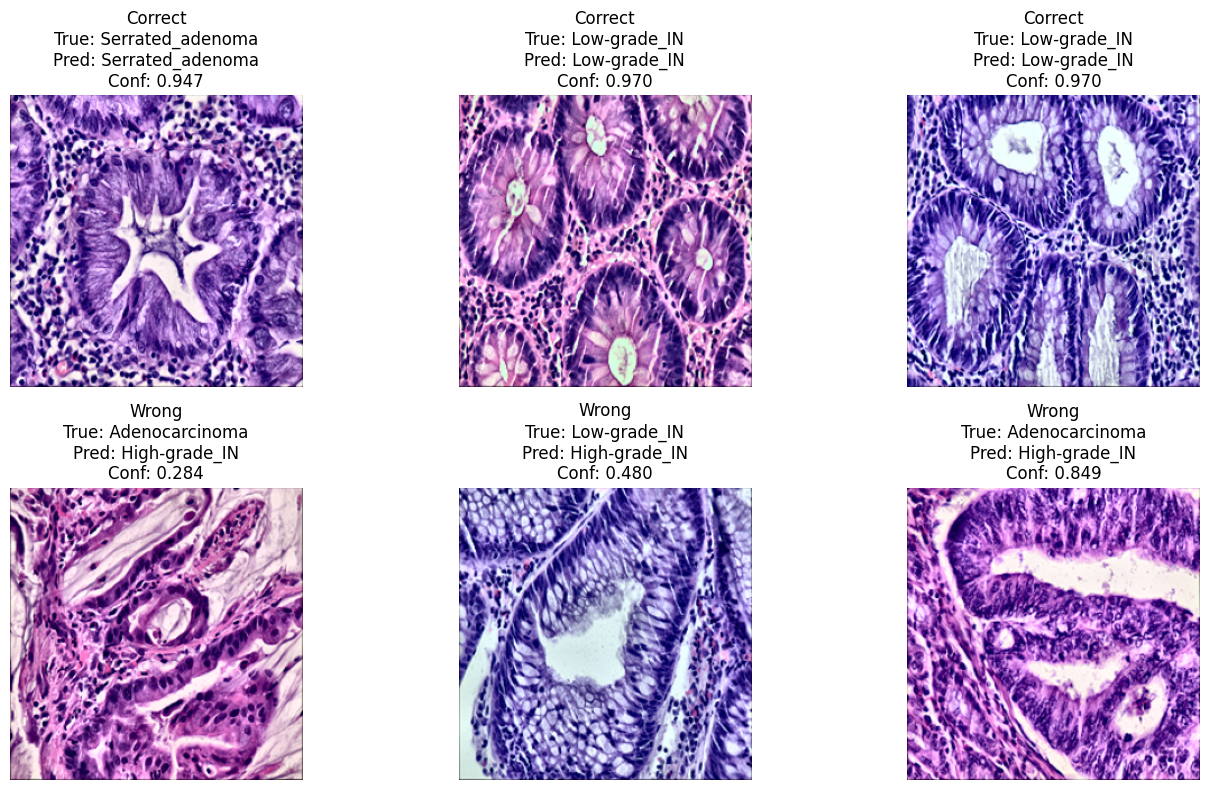

In [ ]:
"""
CELL 3B: Visual Results (Stage 2 - Multi-Class Subtyping)
"""

import random
import torch.nn.functional as F

model_multi.eval()

all_images = []
all_preds = []
all_labels = []
all_probs = []

# ==========================================================
# COLLECT TEST DATA
# ==========================================================
with torch.no_grad():
    for img, label in test_loader_multi:
        img_gpu = img.to(DEVICE, non_blocking=True)

        logits = model_multi(img_gpu)
        probs = F.softmax(logits, dim=1)

        preds = torch.argmax(probs, dim=1)

        all_images.extend(img.cpu())
        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(label.cpu().tolist())
        all_probs.extend(probs.max(dim=1).values.cpu().tolist())


# ==========================================================
# SPLIT CORRECT / INCORRECT
# ==========================================================
correct_idx = [i for i in range(len(all_preds)) if all_preds[i] == all_labels[i]]
wrong_idx   = [i for i in range(len(all_preds)) if all_preds[i] != all_labels[i]]

print(f"Total Correct: {len(correct_idx)}")
print(f"Total Wrong: {len(wrong_idx)}")

num_correct = min(3, len(correct_idx))
num_wrong   = min(3, len(wrong_idx))

correct_samples = random.sample(correct_idx, num_correct) if num_correct > 0 else []
wrong_samples   = random.sample(wrong_idx, num_wrong) if num_wrong > 0 else []


# ==========================================================
# HELPER
# ==========================================================
def denormalize(img):
    img = img.numpy().transpose(1,2,0)
    img = (img * 0.5) + 0.5
    return np.clip(img, 0, 1)


# ==========================================================
# PLOTTING
# ==========================================================
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

# --- CORRECT ---
for i, idx in enumerate(correct_samples):
    ax = axes[0, i]
    ax.imshow(denormalize(all_images[idx]))

    ax.set_title(
        f"Correct\n"
        f"True: {abnormal_classes[all_labels[idx]]}\n"
        f"Pred: {abnormal_classes[all_preds[idx]]}\n"
        f"Conf: {all_probs[idx]:.3f}"
    )
    ax.axis('off')

# --- WRONG ---
for i, idx in enumerate(wrong_samples):
    ax = axes[1, i]
    ax.imshow(denormalize(all_images[idx]))

    ax.set_title(
        f"Wrong\n"
        f"True: {abnormal_classes[all_labels[idx]]}\n"
        f"Pred: {abnormal_classes[all_preds[idx]]}\n"
        f"Conf: {all_probs[idx]:.3f}"
    )
    ax.axis('off')


# fill empty slots if needed
for j in range(len(correct_samples), 3):
    axes[0, j].axis('off')

for j in range(len(wrong_samples), 3):
    axes[1, j].axis('off')

axes[0,0].set_ylabel("Correct", fontsize=12)
axes[1,0].set_ylabel("Wrong", fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
"""
CELL 4: STAGE 3 - UNet++ Boundary-Aware Segmentation (Standalone)
=================================================================
Implements a Dense-Skip UNet++ with synchronized image/mask transforms
and a custom Boundary-Aware Loss Function (BCE + Dice + Edge MSE).
Includes a comprehensive per-class evaluation table.
"""

import os, random, cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torchvision.transforms.functional as TF
import torch.nn.functional as F
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings("ignore")

# ==========================================================
# 0. STANDALONE PREAMBLE: CONFIG, HARVESTING & SPLITS
# ==========================================================
CONFIG = {
    "dataset_root": "/Data/EBHI-SEG",
    "output_dir": os.path.expanduser("~/Documents/simple"),
    "classes": ["Adenocarcinoma", "High-grade_IN", "Low-grade_IN", "Normal", "Polyp", "Serrated_adenoma"],
    "num_classes": 6,
    "image_size": 256,
    "seed": 42,
    "num_workers": 4
}

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(CONFIG["seed"])
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

os.makedirs(os.path.join(CONFIG["output_dir"], "checkpoints"), exist_ok=True)

# DIP Pipeline
def apply_clahe_lab(img_np):
    """Enhances local contrast without distorting H&E stain colors."""
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    lab = cv2.cvtColor(img_np, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    l_eq = clahe.apply(l)
    return cv2.cvtColor(cv2.merge((l_eq, a, b)), cv2.COLOR_LAB2RGB)

# Minimal Data Harvesting
all_data = []
for class_idx, cls_name in enumerate(CONFIG["classes"]):
    img_dir = os.path.join(CONFIG["dataset_root"], cls_name, "image")
    lbl_dir = os.path.join(CONFIG["dataset_root"], cls_name, "label")

    if not os.path.exists(img_dir) or not os.path.exists(lbl_dir):
        continue

    images = sorted([f for f in os.listdir(img_dir) if f.endswith(".png")])
    for img_name in images:
        if os.path.exists(os.path.join(lbl_dir, img_name)):
            bin_label = 0 if cls_name == "Normal" else 1
            all_data.append({
                "img_path": os.path.join(img_dir, img_name),
                "mask_path": os.path.join(lbl_dir, img_name),
                "multi_label": class_idx,
                "bin_label": bin_label,
                "class_name": cls_name
            })

df = pd.DataFrame(all_data)

# Stratified Splits
train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df['multi_label'], random_state=CONFIG["seed"])
val_df, test_df = train_test_split(temp_df, test_size=(2/3), stratify=temp_df['multi_label'], random_state=CONFIG["seed"])

# ==========================================================
# 1. SYNCHRONIZED DATASET (Image + Mask)
# ==========================================================
class SegmentationDataset(Dataset):
    def __init__(self, df, is_train=True):
        self.df = df.reset_index(drop=True)
        self.is_train = is_train

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Load Image (with DIP) and Mask
        img = np.array(Image.open(row['img_path']).convert('RGB'))
        img = apply_clahe_lab(img)
        img = Image.fromarray(img).resize((256, 256))

        mask = Image.open(row['mask_path']).convert('L').resize((256, 256), Image.NEAREST)

        # Apply SYNCHRONIZED transforms
        if self.is_train:
            if random.random() > 0.5:
                img = TF.hflip(img)
                mask = TF.hflip(mask)
            if random.random() > 0.5:
                img = TF.vflip(img)
                mask = TF.vflip(mask)

            # Random slight rotation
            angle = random.uniform(-15, 15)
            img = TF.rotate(img, angle)
            mask = TF.rotate(mask, angle)

            # Color jitter only affects the image, not the mask
            img = transforms.ColorJitter(0.2, 0.2, 0.2, 0.05)(img)

        # Convert to Tensors
        img = TF.to_tensor(img)
        img = TF.normalize(img, [0.5]*3, [0.5]*3)

        mask = TF.to_tensor(mask)
        mask = (mask > 0.5).float() # Ensure binary

        return img, mask

# Loaders for Segmentation
BATCH_SIZE_SEG = 16 # Lower batch size for memory-heavy UNet++

train_loader_seg = DataLoader(SegmentationDataset(train_df, is_train=True),
                              batch_size=BATCH_SIZE_SEG, shuffle=True,
                              num_workers=CONFIG["num_workers"], pin_memory=True)

val_loader_seg = DataLoader(SegmentationDataset(val_df, is_train=False),
                            batch_size=BATCH_SIZE_SEG, shuffle=False,
                            num_workers=CONFIG["num_workers"], pin_memory=True)

test_loader_seg = DataLoader(SegmentationDataset(test_df, is_train=False),
                             batch_size=1, shuffle=False, # BS=1 for accurate metric evaluation
                             num_workers=CONFIG["num_workers"], pin_memory=True)

# ==========================================================
# 2. UNET++ ARCHITECTURE
# ==========================================================
class ConvBlock(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_c), nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_c), nn.ReLU(inplace=True)
        )
    def forward(self, x): return self.conv(x)

class UNetPlusPlus(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, features=[32, 64, 128, 256, 512]):
        super().__init__()
        self.pool = nn.MaxPool2d(2, 2)
        self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)

        # Encoders
        self.conv0_0 = ConvBlock(in_channels, features[0])
        self.conv1_0 = ConvBlock(features[0], features[1])
        self.conv2_0 = ConvBlock(features[1], features[2])
        self.conv3_0 = ConvBlock(features[2], features[3])
        self.conv4_0 = ConvBlock(features[3], features[4])

        # Nested Skip Pathways (The "++" in UNet++)
        self.conv0_1 = ConvBlock(features[0] + features[1], features[0])
        self.conv1_1 = ConvBlock(features[1] + features[2], features[1])
        self.conv2_1 = ConvBlock(features[2] + features[3], features[2])
        self.conv3_1 = ConvBlock(features[3] + features[4], features[3])

        self.conv0_2 = ConvBlock(features[0]*2 + features[1], features[0])
        self.conv1_2 = ConvBlock(features[1]*2 + features[2], features[1])
        self.conv2_2 = ConvBlock(features[2]*2 + features[3], features[2])

        self.conv0_3 = ConvBlock(features[0]*3 + features[1], features[0])
        self.conv1_3 = ConvBlock(features[1]*3 + features[2], features[1])

        self.conv0_4 = ConvBlock(features[0]*4 + features[1], features[0])

        self.final = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        x0_0 = self.conv0_0(x)
        x1_0 = self.conv1_0(self.pool(x0_0))
        x0_1 = self.conv0_1(torch.cat([x0_0, self.up(x1_0)], 1))

        x2_0 = self.conv2_0(self.pool(x1_0))
        x1_1 = self.conv1_1(torch.cat([x1_0, self.up(x2_0)], 1))
        x0_2 = self.conv0_2(torch.cat([x0_0, x0_1, self.up(x1_1)], 1))

        x3_0 = self.conv3_0(self.pool(x2_0))
        x2_1 = self.conv2_1(torch.cat([x2_0, self.up(x3_0)], 1))
        x1_2 = self.conv1_2(torch.cat([x1_0, x1_1, self.up(x2_1)], 1))
        x0_3 = self.conv0_3(torch.cat([x0_0, x0_1, x0_2, self.up(x1_2)], 1))

        x4_0 = self.conv4_0(self.pool(x3_0))
        x3_1 = self.conv3_1(torch.cat([x3_0, self.up(x4_0)], 1))
        x2_2 = self.conv2_2(torch.cat([x2_0, x2_1, self.up(x3_1)], 1))
        x1_3 = self.conv1_3(torch.cat([x1_0, x1_1, x1_2, self.up(x2_2)], 1))
        x0_4 = self.conv0_4(torch.cat([x0_0, x0_1, x0_2, x0_3, self.up(x1_3)], 1))

        return self.final(x0_4)

model_seg = UNetPlusPlus().to(DEVICE)

# ==========================================================
# 3. BOUNDARY-AWARE MULTI-TASK LOSS
# ==========================================================
class BoundaryAwareLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, pred, target):
        # 1. Standard BCE
        bce_loss = self.bce(pred, target)

        pred_sig = torch.sigmoid(pred)

        # 2. Dice Loss (Handles class imbalance of foreground/background pixels)
        intersection = (pred_sig * target).sum(dim=(2, 3))
        union = pred_sig.sum(dim=(2, 3)) + target.sum(dim=(2, 3))
        dice_loss = (1 - (2. * intersection + 1e-5) / (union + 1e-5)).mean()

        # 3. Boundary Edge Loss (Extracts boundaries using MaxPool differential)
        target_edge = F.max_pool2d(target, kernel_size=3, stride=1, padding=1) - target
        pred_edge = F.max_pool2d(pred_sig, kernel_size=3, stride=1, padding=1) - pred_sig
        boundary_loss = F.mse_loss(pred_edge, target_edge)

        # Weighting: Heavily penalize boundary errors
        return bce_loss + dice_loss + (2.0 * boundary_loss)

criterion_seg = BoundaryAwareLoss()
optimizer_seg = optim.AdamW(model_seg.parameters(), lr=2e-4, weight_decay=1e-4)
scaler_seg = torch.amp.GradScaler("cuda")
scheduler_seg = optim.lr_scheduler.CosineAnnealingLR(optimizer_seg, T_max=40)

# ==========================================================
# 4. TRAINING LOOP (AMP ENABLED)
# ==========================================================
def calc_dice(pred, target):
    pred = (torch.sigmoid(pred) > 0.5).float()
    inter = (pred * target).sum()
    return (2. * inter + 1e-5) / (pred.sum() + target.sum() + 1e-5)

best_val_dice = 0.0
epochs_seg = 40
best_model_path = os.path.join(CONFIG["output_dir"], "checkpoints", "stage3_best.pt")

print("Starting Stage 3: Boundary-Aware Segmentation...")
for epoch in range(epochs_seg):
    model_seg.train()
    train_loss, train_dice = 0, 0

    for img, mask in train_loader_seg:
        img, mask = img.to(DEVICE, non_blocking=True), mask.to(DEVICE, non_blocking=True)

        optimizer_seg.zero_grad()
        with torch.amp.autocast("cuda"):
            pred_mask = model_seg(img)
            loss = criterion_seg(pred_mask, mask)

        scaler_seg.scale(loss).backward()
        scaler_seg.step(optimizer_seg)
        scaler_seg.update()

        train_loss += loss.item()
        train_dice += calc_dice(pred_mask, mask).item()

    scheduler_seg.step()

    # Validation Phase
    model_seg.eval()
    val_loss, val_dice = 0, 0
    with torch.no_grad():
        for img, mask in val_loader_seg:
            img, mask = img.to(DEVICE, non_blocking=True), mask.to(DEVICE, non_blocking=True)
            pred_mask = model_seg(img)
            val_loss += criterion_seg(pred_mask, mask).item()
            val_dice += calc_dice(pred_mask, mask).item()

    avg_train_loss = train_loss / len(train_loader_seg)
    avg_val_loss = val_loss / len(val_loader_seg)
    avg_val_dice = val_dice / len(val_loader_seg)

    if avg_val_dice > best_val_dice:
        best_val_dice = avg_val_dice
        torch.save(model_seg.state_dict(), best_model_path)

    print(f"Epoch {epoch+1:02d} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Dice: {avg_val_dice:.4f}")

# ==========================================================
# 5. FINAL TEST EVALUATION & METRIC TABLE SUMMARY
# ==========================================================
# Exact implementations for Advanced Table Metrics
def calc_bf_score(pred_mask, true_mask, max_dist=2):
    """Computes Boundary F1-score matching edges within a spatial pixel tolerance."""
    p = (pred_mask > 0).astype(np.uint8)
    t = (true_mask > 0).astype(np.uint8)

    if p.sum() == 0 and t.sum() == 0: return 1.0
    if p.sum() == 0 or t.sum() == 0: return 0.0

    kernel = np.ones((3, 3), np.uint8)
    p_edge = cv2.dilate(p, kernel) - p
    t_edge = cv2.dilate(t, kernel) - t

    if p_edge.sum() == 0 and t_edge.sum() == 0: return 1.0
    if p_edge.sum() == 0 or t_edge.sum() == 0: return 0.0

    relax_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (max_dist*2+1, max_dist*2+1))
    t_edge_dilated = cv2.dilate(t_edge, relax_kernel)
    p_edge_dilated = cv2.dilate(p_edge, relax_kernel)

    precision = np.logical_and(p_edge, t_edge_dilated).sum() / (p_edge.sum() + 1e-8)
    recall = np.logical_and(t_edge, p_edge_dilated).sum() / (t_edge.sum() + 1e-8)

    if precision + recall == 0: return 0.0
    return 2.0 * precision * recall / (precision + recall)

def calc_hog_sim(pred_mask, true_mask):
    """Computes Histogram of Oriented Gradients cosine similarity on mask contours."""
    p = (pred_mask > 0).astype(np.float32)
    t = (true_mask > 0).astype(np.float32)

    if p.sum() == 0 and t.sum() == 0: return 1.0

    gx_p = cv2.Sobel(p, cv2.CV_32F, 1, 0, ksize=3)
    gy_p = cv2.Sobel(p, cv2.CV_32F, 0, 1, ksize=3)
    mag_p, ang_p = cv2.cartToPolar(gx_p, gy_p, angleInDegrees=True)

    gx_t = cv2.Sobel(t, cv2.CV_32F, 1, 0, ksize=3)
    gy_t = cv2.Sobel(t, cv2.CV_32F, 0, 1, ksize=3)
    mag_t, ang_t = cv2.cartToPolar(gx_t, gy_t, angleInDegrees=True)

    hist_p, _ = np.histogram(ang_p, bins=8, range=(0, 360), weights=mag_p)
    hist_t, _ = np.histogram(ang_t, bins=8, range=(0, 360), weights=mag_t)

    norm_p = np.linalg.norm(hist_p)
    norm_t = np.linalg.norm(hist_t)

    if norm_p == 0 and norm_t == 0: return 1.0
    if norm_p == 0 or norm_t == 0: return 0.0
    return float(np.dot(hist_p, hist_t) / (norm_p * norm_t))

def calc_dice_jaccard(pred_mask, true_mask):
    p = (pred_mask > 0).astype(np.float32)
    t = (true_mask > 0).astype(np.float32)
    inter = np.logical_and(p, t).sum()
    union = np.logical_or(p, t).sum()
    if p.sum() == 0 and t.sum() == 0: return 1.0, 1.0
    return float(2.0 * inter / (p.sum() + t.sum() + 1e-8)), float(inter / (union + 1e-8))

def calc_cc(pred_mask, true_mask):
    """Computes Pearson Correlation Coefficient between segmentation masks."""
    p = (pred_mask > 0).astype(np.float32).flatten()
    t = (true_mask > 0).astype(np.float32).flatten()
    p_diff = p - p.mean()
    t_diff = t - t.mean()
    den = np.linalg.norm(p_diff) * np.linalg.norm(t_diff)
    if den == 0: return 1.0 if (p == t).all() else 0.0
    return float(np.dot(p_diff, t_diff) / den)

# Run Inference & Populate Table
model_seg.load_state_dict(torch.load(best_model_path))
model_seg.eval()

# Accumulate per-class results
class_metrics = {cls: {"bf": [], "hog": [], "dice": [], "jaccard": [], "cc": []} for cls in CONFIG["classes"]}

with torch.no_grad():
    # Since test_loader_seg is un-shuffled, enumerate indices align perfectly with test_df
    for idx, (img, mask) in enumerate(tqdm(test_loader_seg, desc="Aggregating Table Metrics")):
        img = img.to(DEVICE, non_blocking=True)

        pred_probs = torch.sigmoid(model_seg(img))
        pred_bin = (pred_probs > 0.5).cpu().numpy().squeeze()
        true_bin = mask.cpu().numpy().squeeze()

        cls_name = test_df.iloc[idx]['class_name']

        bf = calc_bf_score(pred_bin, true_bin)
        hog = calc_hog_sim(pred_bin, true_bin)
        dice, jaccard = calc_dice_jaccard(pred_bin, true_bin)
        cc = calc_cc(pred_bin, true_bin)

        class_metrics[cls_name]["bf"].append(bf)
        class_metrics[cls_name]["hog"].append(hog)
        class_metrics[cls_name]["dice"].append(dice)
        class_metrics[cls_name]["jaccard"].append(jaccard)
        class_metrics[cls_name]["cc"].append(cc)

# Compile tabular output via Pandas
table_rows = []
avg_bf, avg_hog, avg_dice, avg_jac, avg_cc = [], [], [], [], []

for cls_name in CONFIG["classes"]:
    if not class_metrics[cls_name]["dice"]: # Skip if class absent in test split
        continue

    m_bf  = np.mean(class_metrics[cls_name]["bf"])
    m_hog = np.mean(class_metrics[cls_name]["hog"])
    m_dic = np.mean(class_metrics[cls_name]["dice"])
    m_jac = np.mean(class_metrics[cls_name]["jaccard"])
    m_cc  = np.mean(class_metrics[cls_name]["cc"])

    table_rows.append({
        "Class": cls_name, "BF-score": m_bf, "HOG-sim": m_hog,
        "Dice": m_dic, "Jaccard": m_jac, "CC": m_cc
    })

    avg_bf.append(m_bf); avg_hog.append(m_hog); avg_dice.append(m_dic)
    avg_jac.append(m_jac); avg_cc.append(m_cc)

metrics_df = pd.DataFrame(table_rows)

# Append macro average row
mean_row = pd.DataFrame([{
    "Class": "Average", "BF-score": np.mean(avg_bf), "HOG-sim": np.mean(avg_hog),
    "Dice": np.mean(avg_dice), "Jaccard": np.mean(avg_jac), "CC": np.mean(avg_cc)
}])

final_table_df = pd.concat([metrics_df, mean_row], ignore_index=True)

print("\n=== STAGE 3: SEGMENTATION METRICS SUMMARY ===")
print(final_table_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

Starting Stage 3: Boundary-Aware Segmentation...
Epoch 01 | Train Loss: 0.7568 | Val Loss: 0.6212 | Val Dice: 0.8996
Epoch 02 | Train Loss: 0.5718 | Val Loss: 0.5255 | Val Dice: 0.9074
Epoch 03 | Train Loss: 0.4957 | Val Loss: 0.4887 | Val Dice: 0.9204
Epoch 04 | Train Loss: 0.4476 | Val Loss: 0.4675 | Val Dice: 0.9239
Epoch 05 | Train Loss: 0.4113 | Val Loss: 0.3959 | Val Dice: 0.9347
Epoch 06 | Train Loss: 0.3824 | Val Loss: 0.3761 | Val Dice: 0.9385
Epoch 07 | Train Loss: 0.3704 | Val Loss: 0.3706 | Val Dice: 0.9378
Epoch 08 | Train Loss: 0.3479 | Val Loss: 0.3485 | Val Dice: 0.9428
Epoch 09 | Train Loss: 0.3345 | Val Loss: 0.3477 | Val Dice: 0.9404
Epoch 10 | Train Loss: 0.3247 | Val Loss: 0.3151 | Val Dice: 0.9471
Epoch 11 | Train Loss: 0.3151 | Val Loss: 0.3463 | Val Dice: 0.9391
Epoch 12 | Train Loss: 0.3106 | Val Loss: 0.3160 | Val Dice: 0.9459
Epoch 13 | Train Loss: 0.3070 | Val Loss: 0.3053 | Val Dice: 0.9472
Epoch 14 | Train Loss: 0.2980 | Val Loss: 0.2994 | Val Dice: 0.9482

Aggregating Table Metrics:   0%|          | 0/446 [00:00<?, ?it/s]


=== STAGE 3: SEGMENTATION METRICS SUMMARY ===
           Class  BF-score  HOG-sim   Dice  Jaccard     CC
  Adenocarcinoma    0.5683   0.9597 0.9264   0.8691 0.7424
   High-grade_IN    0.7484   0.9921 0.9491   0.9046 0.8453
    Low-grade_IN    0.8643   0.9938 0.9699   0.9436 0.9132
          Normal    0.9015   0.9961 0.9696   0.9417 0.9199
           Polyp    0.9081   0.9960 0.9696   0.9415 0.9321
Serrated_adenoma    0.8298   0.9969 0.9669   0.9363 0.9130
         Average    0.8034   0.9891 0.9586   0.9228 0.8777


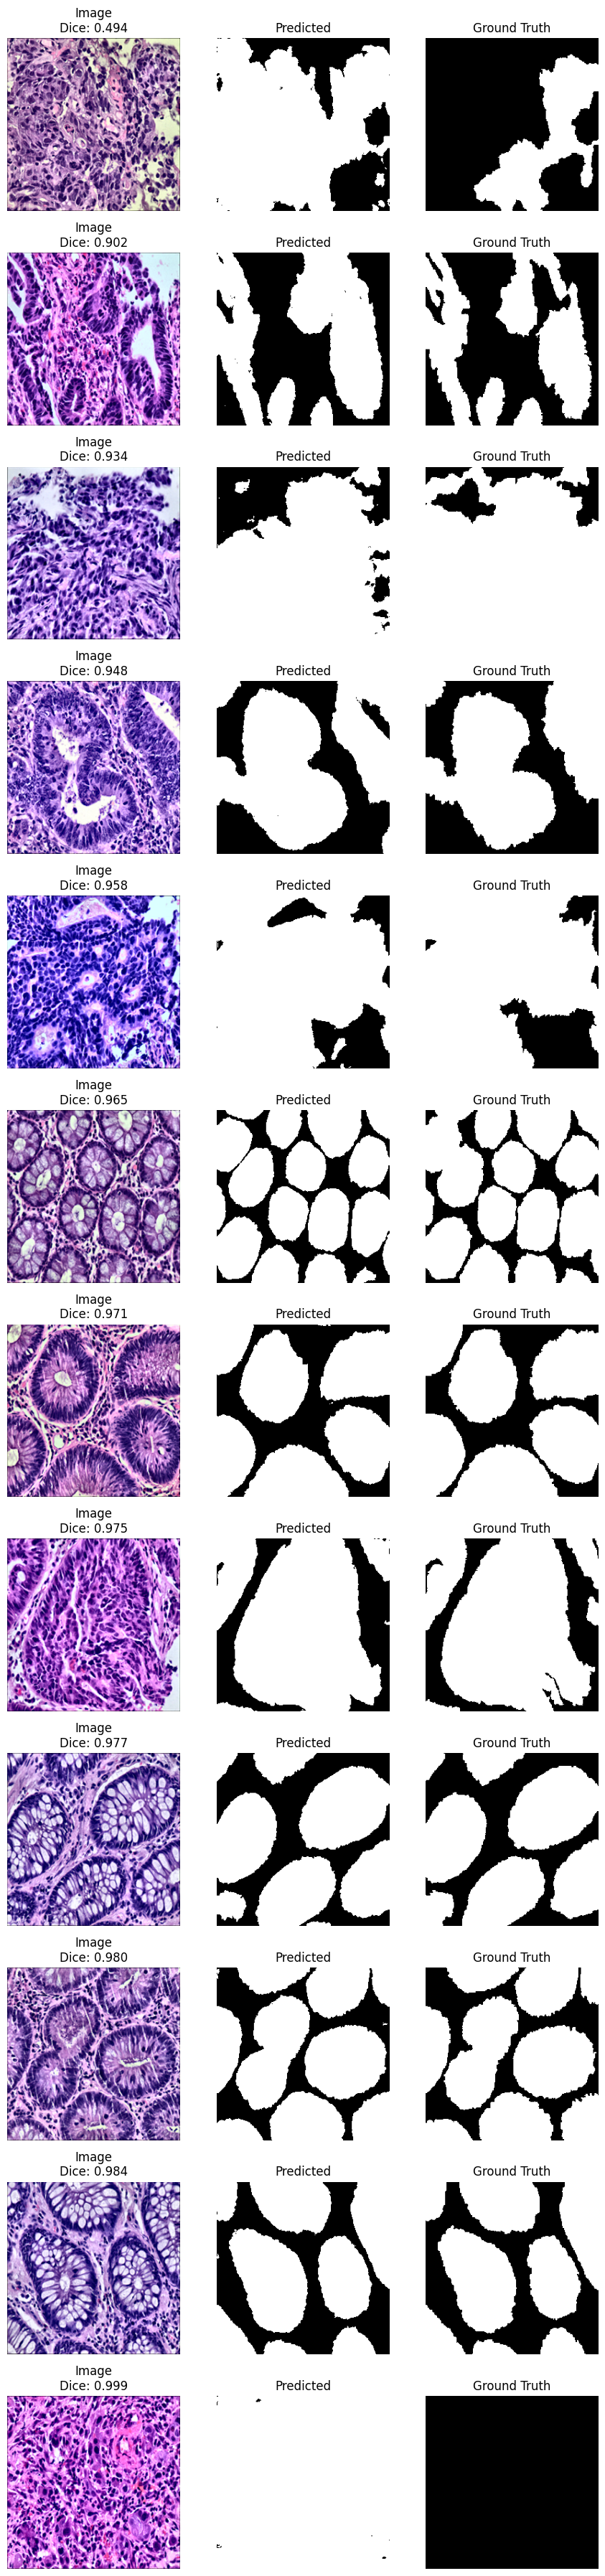

In [ ]:
"""
CELL 4B: Visual Results (Stage 3 - Segmentation Worst → Best)
"""

model_seg.eval()

all_imgs = []
all_preds = []
all_masks = []
all_dice = []

# ==========================================================
# COLLECT TEST RESULTS
# ==========================================================
with torch.no_grad():
    for img, mask in test_loader_seg:
        img_gpu = img.to(DEVICE, non_blocking=True)
        mask_gpu = mask.to(DEVICE, non_blocking=True)

        pred = model_seg(img_gpu)

        # compute dice
        dice = calc_dice(pred, mask_gpu).item()

        pred_bin = (torch.sigmoid(pred) > 0.5).float()

        all_imgs.append(img.cpu())
        all_preds.append(pred_bin.cpu())
        all_masks.append(mask.cpu())
        all_dice.append(dice)


# ==========================================================
# SORT WORST → BEST
# ==========================================================
indices = list(range(len(all_dice)))
indices.sort(key=lambda x: all_dice[x])  # ascending

# pick 12 evenly spaced across spectrum
num_samples = min(12, len(indices))
selected_idx = np.linspace(0, len(indices)-1, num_samples, dtype=int)
selected_idx = [indices[i] for i in selected_idx]


# ==========================================================
# HELPER
# ==========================================================
def denorm(img):
    img = img.numpy().transpose(1,2,0)
    img = (img * 0.5) + 0.5
    return np.clip(img, 0, 1)

def to_mask(x):
    return x.squeeze().numpy()


# ==========================================================
# PLOTTING (3 columns: img | pred | gt)
# ==========================================================
fig, axes = plt.subplots(num_samples, 3, figsize=(9, 3*num_samples))

for i, idx in enumerate(selected_idx):
    img = denorm(all_imgs[idx][0])
    pred = to_mask(all_preds[idx][0])
    gt   = to_mask(all_masks[idx][0])
    dice = all_dice[idx]

    # original
    axes[i,0].imshow(img)
    axes[i,0].set_title(f"Image\nDice: {dice:.3f}")
    axes[i,0].axis('off')

    # predicted
    axes[i,1].imshow(pred, cmap='gray')
    axes[i,1].set_title("Predicted")
    axes[i,1].axis('off')

    # ground truth
    axes[i,2].imshow(gt, cmap='gray')
    axes[i,2].set_title("Ground Truth")
    axes[i,2].axis('off')


plt.tight_layout()
plt.show()